# ④ 탐지 규칙 설계

기획안 3.4절(④-1 ~ ④-5)을 순서대로 실행합니다. **`DATA_PATH`만 바꾸면 위에서부터 그대로 돌아갑니다.**

| 단계 | 정하는 것 | 판정 기준 |
|---|---|---|
| ④-1 | 비교 기준 (직전 기간 / 작년 같은 달) | 계절성: 연도 쌍 상관계수 검정 3개 모두 p<0.05(단측) + 월별 분산분석 p<0.05 → 두 방식 중 월별 탐지율 최대/최소가 작은 쪽 |
| ④-2 | 창 길이 K | 일시적 하락 비율 < 20%인 가장 짧은 창 (없으면 창을 늘려도 신뢰구간상 뚜렷하게 줄지 않는 첫 창) |
| ④-3 | 금액 하한 | 분위별 변화율 IQR ≤ 상위 5개 분위 IQR 중앙값 × 1.5 |
| ④-4 | 판정 기간 | 비교 기간 + 사후 6개월로 계산 |
| ④-5 | 변화율 분포 | 기술통계, 5번째 백분위수(⑤-1 후보) |

그래프는 셀을 실행하면 화면에 바로 나옵니다. 그림·표를 파일로도 남기려면 설정 셀의 `SAVE = True`로 바꾸세요.

## 설정

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

DATA_PATH = Path(r"데이터입력")   # ← 데이터 경로 (csv / xlsx / parquet)
SHEET = 0                                     # 엑셀이면 시트 번호 또는 이름
SAVE = False                                  # True로 바꾸면 그림(PNG)·표(CSV)를 OUT_DIR에 저장
OUT_DIR = Path("output/04_탐지규칙설계")     # 저장 폴더
if SAVE:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL, MONTH_COL, AMT_COL = "법인ID", "기준년월", "요구불입금금액"

# ---- 임시값 (⑤에서 n이 정해지면 마지막 셀에서 다시 확인) ----
TH_TEMP = -0.30       # 임시 감소 기준 30%
K_TEMP = 3            # 임시 창 길이 3개월

# ---- 판정 기준 (기획안에 사전 확정한 값) ----
ALPHA = 0.05          # 유의수준
TRANSIENT_MAX = 0.20  # ④-2 일시적 하락 비율 상한
BACK_RATIO = 0.90     # ④-2 '원래 수준 복귀' = 비교 기간 평균의 90% 이상
IQR_MULT = 1.5        # ④-3 IQR 허용 배수
FOLLOW = 6            # 사후 추적 개월 수
WINDOWS = [1, 2, 3, 6]
END_T = 35 - FOLLOW   # 판정 마지막 달 (0부터 셈: 29 = 2025.06)

In [2]:
# ---- 그래프 기본 설정 ----
_names = {f.name for f in fm.fontManager.ttflist}
_pick = next((n for n in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans KR", "Noto Sans CJK KR"] if n in _names),
             next((n for n in sorted(_names) if "Nanum" in n or "Sans CJK" in n), None))
if _pick:
    mpl.rcParams["font.family"] = _pick
else:
    print("한글 글꼴을 찾지 못했습니다. 그래프의 한글이 깨지면 맑은 고딕 등을 설치하세요.")
mpl.rcParams.update({
    "axes.unicode_minus": False, "figure.dpi": 110, "savefig.dpi": 200,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b9b8b2", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "axes.grid.axis": "y", "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "legend.frameon": False, "font.size": 10, "axes.axisbelow": True,
})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"   # 계열 색 1~3 (고정 순서)
MUTED, INK, LIGHT = "#8a8984", "#52514e", "#c9d8ee"

def save(fig, name):
    fig.tight_layout()
    if SAVE:
        fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    plt.show()

decisions = {}   # 단계별 결정 사항 모음

## 0. 데이터 읽기 · 결측 제외 · 기업×월 행렬

36개월이 모두 있고 입금 결측이 없는 기업만 남깁니다. 이미 그렇게 정리된 파일이면 아무것도 빠지지 않습니다.

In [3]:
def read_data(path, sheet=0):
    path = Path(path)
    cols = [ID_COL, MONTH_COL, AMT_COL]
    kind = path.suffix.lower()
    if kind in (".xlsx", ".xlsm", ".xls"):
        return pd.read_excel(path, sheet_name=sheet, usecols=cols, dtype={ID_COL: str, MONTH_COL: str})
    if kind == ".parquet":
        return pd.read_parquet(path, columns=cols)
    for enc in ("utf-8-sig", "cp949"):
        try:
            return pd.read_csv(path, usecols=cols, dtype={ID_COL: str, MONTH_COL: str}, encoding=enc)
        except UnicodeDecodeError:
            continue
    raise ValueError("CSV 인코딩을 확인하세요")

df = read_data(DATA_PATH, SHEET)
df[ID_COL] = df[ID_COL].astype(str)
df[MONTH_COL] = df[MONTH_COL].astype(str).str.replace(r"\D", "", regex=True).str[:6]
if not pd.api.types.is_numeric_dtype(df[AMT_COL]):
    df[AMT_COL] = pd.to_numeric(df[AMT_COL].astype("string").str.replace(",", "", regex=False), errors="coerce")
df[AMT_COL] = df[AMT_COL].astype(float)

months = sorted(df[MONTH_COL].unique())
assert len(months) == 36, f"월 개수가 {len(months)}개입니다"

n_before = df[ID_COL].nunique()
g = df.groupby(ID_COL)
keep = g[MONTH_COL].nunique().eq(36) & g[AMT_COL].apply(lambda s: s.notna().all())
df = df[df[ID_COL].isin(keep[keep].index)].copy()

print(f"전체 기업 {n_before:,}개 → 분석 기업 {df[ID_COL].nunique():,}개, {len(df):,}행")
assert not df.duplicated([ID_COL, MONTH_COL]).any()

전체 기업 15,473개 → 분석 기업 3,372개, 121,392행


In [4]:
wide = df.pivot(index=ID_COL, columns=MONTH_COL, values=AMT_COL)[months]
dep = wide.to_numpy(float)      # dep[i, t]: i번째 기업, t번째 달 (t=0 → 2023.01, t=35 → 2025.12)
N = len(dep)
label = [f"{m[:4]}.{m[4:]}" for m in months]
print(dep.shape)

(3372, 36)


## 공통 함수

- `roll(x, k)` : t월까지 최근 k개월 평균
- `change(x, k, mode)` : 변화율 = (최근 k개월 평균 − 비교 k개월 평균) ÷ 비교 k개월 평균
  - `mode="yoy"` : 작년 같은 k개월과 비교 / `mode="prev"` : 바로 앞 k개월과 비교
  - 비교 평균이 0이면 계산하지 않음(NaN)

In [5]:
def roll(x, k):
    c = np.cumsum(np.c_[np.zeros(len(x)), x], axis=1)
    out = np.full_like(x, np.nan)
    out[:, k-1:] = (c[:, k:] - c[:, :-k]) / k
    return out

def lag_of(k, mode):
    return 12 if mode == "yoy" else k

def change(x, k, mode="yoy"):
    r = roll(x, k)
    lag = lag_of(k, mode)
    base = np.full_like(r, np.nan)
    base[:, lag:] = r[:, :-lag]
    with np.errstate(divide="ignore", invalid="ignore"):
        ch = np.where(base > 0, (r - base) / base, np.nan)
    return ch, base

def first_t(k, mode):
    # 비교 자료가 있는 첫 달 (0부터 셈)
    return (k - 1) + lag_of(k, mode)

def prop_ci(x, n):
    p = x / n
    h = 1.96 * np.sqrt(p * (1 - p) / n)
    return p, p - h, p + h

## ④-1. 비교 기준

### 1단계: 계절성이 있는가

- **월별 지수(연도, 월)** = 그 달 기업 입금 중앙값 ÷ 그 해 12개월 중앙값들의 평균
- **반복성**: 연도 쌍(23–24, 23–25, 24–25) 피어슨 상관계수 검정 — H0: ρ ≤ 0 / H1: ρ > 0 (단측, 자유도 10)
- **월별 차이**: 월별 일원분산분석 — H0: 12개 월의 평균 지수가 모두 같다 (월마다 3개 연도 값)
- 둘 다 유의하면 **계절성 있음**

In [30]:
tmp = df.assign(연=df[MONTH_COL].str[:4], 월=df[MONTH_COL].str[4:].astype(int))
med = tmp.groupby(["연", "월"])[AMT_COL].median().unstack("월")
idx = med.div(med.mean(axis=1), axis=0)            # 3년 × 12개월 월별 지수

def corr_test_greater(a, b):
    r = np.corrcoef(a, b)[0, 1]
    df_ = len(a) - 2
    t = r * np.sqrt(df_ / (1 - r**2))
    return r, stats.t.sf(t, df_)                   # 단측 p값

years = list(idx.index)
rows = []
for i in range(len(years)):
    for j in range(i + 1, len(years)):
        r, p = corr_test_greater(idx.loc[years[i]].values, idx.loc[years[j]].values)
        rows.append({"연도 쌍": f"{years[i]}–{years[j]}", "상관계수": r, "p값(단측)": p, "유의": p < ALPHA})
corr_tab = pd.DataFrame(rows)

F, p_anova = stats.f_oneway(*[idx[m].values for m in idx.columns])
r_crit = (lambda t: t / np.sqrt(t**2 + 10))(stats.t.ppf(1 - ALPHA, 10))

repeat_ok = corr_tab["유의"].all()
month_ok = p_anova < ALPHA
seasonal = bool(repeat_ok and month_ok)

display(idx.round(3))
display(corr_tab.round(4))
print(f"단측 5% 상관계수 임계값(자유도 10): {r_crit:.3f}")
print(f"월별 분산분석: F = {F:.2f}, p = {p_anova:.4g}")
print("→ 계절성", "있음" if seasonal else "없음",
      f"(반복성 {'충족' if repeat_ok else '미충족'}, 월별 차이 {'충족' if month_ok else '미충족'})")

월,1,2,3,4,5,6,7,8,9,10,11,12
연,,,,,,,,,,,,
2023,0.945,0.841,1.039,0.898,1.039,1.039,0.945,0.945,1.039,0.907,1.039,1.323
2024,1.066,0.940,0.911,1.066,0.969,0.964,1.066,0.901,0.969,0.964,0.921,1.260
2025,0.956,0.902,0.994,1.031,0.913,1.058,1.010,0.902,1.074,0.978,0.892,1.289


,연도 쌍,상관계수,p값(단측),유의
0,2023–2024,0.5690,0.0268,True
1,2023–2025,0.7529,0.0024,True
2,2024–2025,0.8023,0.0008,True


단측 5% 상관계수 임계값(자유도 10): 0.497
월별 분산분석: F = 8.72, p = 5.636e-06
→ 계절성 있음 (반복성 충족, 월별 차이 충족)


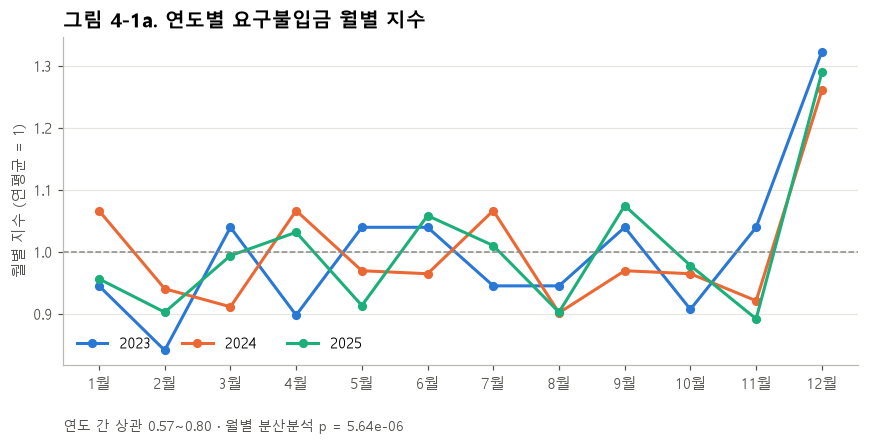

In [31]:
fig, ax = plt.subplots(figsize=(8, 4.2))
for y, c in zip(years, [C1, C2, C3]):
    ax.plot(range(1, 13), idx.loc[y].values, color=c, lw=2, marker="o", ms=5, label=y)
ax.axhline(1, color=MUTED, lw=1, ls="--")
ax.set_xticks(range(1, 13), [f"{m}월" for m in range(1, 13)])
ax.set_ylabel("월별 지수 (연평균 = 1)")
ax.set_title("그림 4-1a. 연도별 요구불입금 월별 지수")
ax.text(0, -0.2, f"연도 간 상관 {corr_tab['상관계수'].min():.2f}~{corr_tab['상관계수'].max():.2f} · "
        f"월별 분산분석 p = {p_anova:.3g}", transform=ax.transAxes, color=INK, fontsize=9)
ax.legend(loc="lower left", ncol=3)
save(fig, "4-1a_연도별_월지수")

**[그림 4-1a 해석]**
- 12월이 매년 연평균보다 26~32% 높음 → 연말 결산·대금 지급 집중 효과 (가장 뚜렷한 계절성)
- 11월은 2024·2025년에 낮음 → 대금 지급이 12월로 미뤄진 영향으로 추정
- 2월(짧은 달·설 연휴)과 8월(하계휴가철)은 세 해 모두 평균보다 낮음
- 나머지 달은 해마다 위아래가 엇갈림 → 고정된 계절이라기보다 그해 영업일수 차이로 보임
- 연도 간 상관(0.57~0.80)은 주로 12월이 만든 것 → "연말 효과가 매년 반복된다"로 해석
- 시사점: 직전 기간과 비교하면 12월 다음 달인 1월에 정상 기업이 위축으로 잘못 잡힘 → 작년 같은 달과 비교하는 방식이 필요한 근거

### 2단계: 어느 비교 방식이 안정적인가 (임시값: 창 3개월, 감소 30%)

두 방식으로 월별 탐지율(탐지 기업 수 ÷ 판정 대상 기업 수)을 구하고 **최대 ÷ 최소**를 비교합니다. 두 방식 모두 같은 달(작년 비교가 가능한 첫 달 ~ 2025.06)을 씁니다.

※ 월 × 탐지 여부 카이제곱 검정은 같은 기업이 여러 달에 반복 포함돼 독립 가정이 맞지 않으므로 참고값으로만 표시합니다.

In [32]:
def monthly_rate(mode, k, th):
    ch, _ = change(dep, k, mode)
    T = range(first_t(k, "yoy"), END_T + 1)        # 두 방식 공통 기간
    rows = []
    for t in T:
        v = ch[:, t]; ok = ~np.isnan(v)
        rows.append({"월": label[t], "탐지": int((v[ok] <= th).sum()), "대상": int(ok.sum())})
    m = pd.DataFrame(rows)
    m["탐지율"] = m["탐지"] / m["대상"]
    return m

def compare_methods(k, th):
    out, rates = [], {}
    for mode, name in [("prev", "직전 기간 비교"), ("yoy", "작년 같은 달 비교")]:
        m = monthly_rate(mode, k, th)
        rates[mode] = m
        chi2, p, *_ = stats.chi2_contingency(np.c_[m["탐지"], m["대상"] - m["탐지"]])
        out.append({"방식": name, "mode": mode, "최소 탐지율": m["탐지율"].min(), "최대 탐지율": m["탐지율"].max(),
                    "최대/최소": m["탐지율"].max() / m["탐지율"].min(), "카이제곱 p(참고)": p})
    return pd.DataFrame(out), rates

method_tab, rates = compare_methods(K_TEMP, TH_TEMP)
if seasonal:
    METHOD = method_tab.loc[method_tab["최대/최소"].idxmin(), "mode"]
    why = "계절성 있음 → 월별 탐지율이 덜 흔들리는 방식"
else:
    METHOD = "prev"
    why = "계절성 없음 → 더 최근 정보를 쓰는 직전 기간 비교"
decisions["④-1 비교 기준"] = ("작년 같은 달" if METHOD == "yoy" else "직전 기간", why)

display(method_tab.drop(columns="mode").round(4))
print("→ 채택:", decisions["④-1 비교 기준"])

,방식,최소 탐지율,최대 탐지율,최대/최소,카이제곱 p(참고)
0,직전 기간 비교,0.1654,0.2831,1.7122,0.0
1,작년 같은 달 비교,0.2100,0.2712,1.2913,0.0


→ 채택: ('작년 같은 달', '계절성 있음 → 월별 탐지율이 덜 흔들리는 방식')


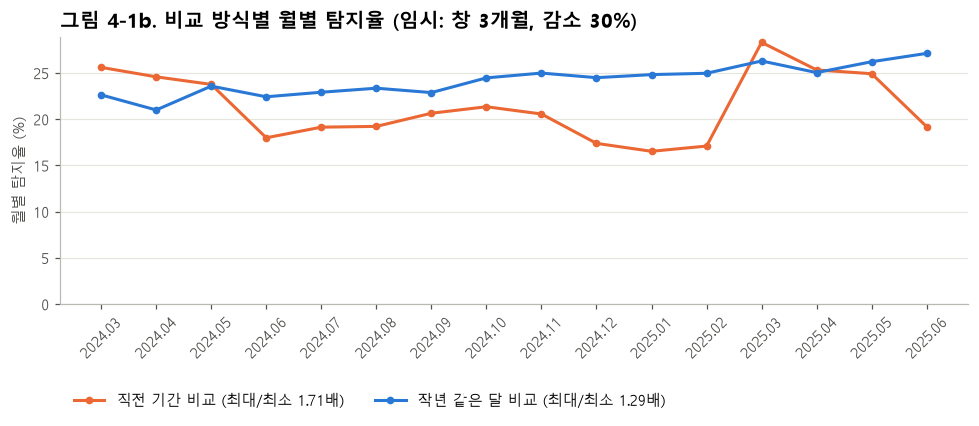

In [33]:
fig, ax = plt.subplots(figsize=(9, 4.2))
for mode, c, name in [("prev", C2, "직전 기간 비교"), ("yoy", C1, "작년 같은 달 비교")]:
    m = rates[mode]
    ratio = m["탐지율"].max() / m["탐지율"].min()
    ax.plot(m["월"], m["탐지율"] * 100, color=c, lw=2, marker="o", ms=4, label=f"{name} (최대/최소 {ratio:.2f}배)")
ax.set_ylabel("월별 탐지율 (%)")
ax.set_ylim(bottom=0)
ax.tick_params(axis="x", rotation=45)
ax.set_title(f"그림 4-1b. 비교 방식별 월별 탐지율 (임시: 창 {K_TEMP}개월, 감소 {abs(TH_TEMP):.0%})")
ax.legend(loc="upper left", bbox_to_anchor=(0, -0.28), ncol=2)
save(fig, "4-1b_비교방식별_월별탐지율")

**④-1 2단계 결과 해석**

- 작년 같은 달 비교의 월별 탐지율은 21.0~27.1%로, 최대/최소가 1.29배다.
- 직전 기간 비교는 16.5~28.3%로 1.71배다. 달에 따라 탐지율이 더 크게 흔들린다.
- 직전 기간 비교의 흔들림은 연말 효과(12월 입금 집중, 그림 4-1a) 때문으로 보인다. 비교 기간에 12월이 들어가는 달은 정상 기업도 감소한 것처럼 잡힌다.
- 따라서 계절 영향을 덜 받는 **작년 같은 달 비교**를 채택한다.
- 작년 같은 달 비교에도 1.29배의 흔들림이 남는다. 설·추석처럼 해마다 달이 바뀌는 연휴로 영업일수가 달라지는 영향, 또는 실제 경기 변화로 추정한다.
- 임시 기준(3개월, 30% 감소)에서 매달 기업의 약 21~27%가 탐지된다. 30% 감소는 흔하게 일어나는 수준이라는 뜻이다. 그래서 ⑤에서 더 엄격한 기준(n%)을 통계적으로 정할 필요가 있다.
- 카이제곱 p값(0.0)은 같은 기업이 여러 달에 반복해서 들어가 독립 가정이 맞지 않으므로 판정에 쓰지 않는다.

## ④-2. 창 길이 K

**목적:** 몇 개월 평균으로 비교할 때 "지속되는 감소"를 가장 잘 가려내는지 확인한다.

**주 지표: 지속률**
- 지속률 = 탐지된 기업 중, 탐지 4~6개월 뒤 3개월 평균 입금이 작년 같은 3개월보다 감소 기준(임시 30%) 이상 줄어 있는 비율
- 결과 구간(t+4~t+6)은 모든 창에 동일하고, 어느 창의 탐지 기간과도 겹치지 않는다.
- 기준선 = 공통 판정 기간의 모든 기업-월에서 같은 감소가 나타나는 비율. 지속비 = 지속률 ÷ 기준선

**보조 지표:** 일시적 하락 비율(탐지 다음 달 입금이 비교 기간 평균의 90% 이상으로 회복), 판정 가능 개월 수, 탐지 기업 수

**결정 규칙 (사전 확정):** 지속률이 가장 높은 창과 비교해 두 비율 z검정(유의수준 5%)에서 유의하게 낮지 않은 창 중 가장 짧은 창
- 가려내는 힘이 같다고 볼 수 있으면, 더 빨리 탐지하고 판정 기간이 긴 짧은 창을 쓴다.
- 창끼리 같은 기업이 겹쳐 z검정은 근사적이다(보수적).

- 후보: 1~6개월, 공통 판정 기간 2024.06~2025.06, 기업별 첫 탐지 1건

In [54]:
# ④-2-1. 후보 창별 평가표
CAND = [1, 2, 3, 4, 5, 6]
T0 = max(first_t(k, METHOD) for k in CAND)       # 공통 판정 기간 시작 (모든 후보가 계산 가능한 첫 달)
TS = range(T0, END_T + 1)

# 공통 결과 지표: 탐지 4~6개월 뒤에도 작년 같은 달보다 감소 기준 이상 줄어 있는가 (창 길이와 무관하게 동일)
F3 = roll(dep, 3)
def persists(i, t, th=TH_TEMP):
    fut, base = F3[i, t + 6], F3[i, t - 6]        # t+4~t+6 평균 vs 작년 같은 3개월(t-8~t-6) 평균
    with np.errstate(divide="ignore", invalid="ignore"):
        chg = np.where(base > 0, (fut - base) / base, np.nan)
    return chg <= th, ~np.isnan(chg)

def first_detect(k, th=TH_TEMP):
    # 공통 판정 기간 안에서 기업별 첫 탐지월(없으면 -1)과 비교 기간 평균
    ch, base = change(dep, k, METHOD)
    d = ch[:, T0:END_T + 1] <= th
    return np.where(d.any(axis=1), d.argmax(axis=1) + T0, -1), base

def evaluate(k, th=TH_TEMP, back_ratio=BACK_RATIO):
    f, base = first_detect(k, th)
    i = np.where(f >= 0)[0]; t = f[i]
    p_flag, p_ok = persists(i, t, th)                          # 주 지표: 지속률
    sp, slo, shi = prop_ci(p_flag[p_ok].sum(), p_ok.sum())
    back = dep[i, t + 1] >= back_ratio * base[i, t]            # 보조 지표: 일시적 하락
    tp, tlo, thi = prop_ci(back.sum(), len(i))
    return {"창": k, "탐지 기업": len(i),
            "지속률": sp, "지속률 하한": slo, "지속률 상한": shi,
            "일시적 하락": tp, "일시적 하락 하한": tlo, "일시적 하락 상한": thi,
            "판정 가능 개월 수": END_T - first_t(k, METHOD) + 1}

# 기준선: 공통 기간의 모든 기업-월에서 4~6개월 뒤 감소가 나타나는 비율 (탐지와 무관한 평균 수준)
ii, tt = np.meshgrid(np.arange(N), np.array(TS), indexing="ij")
flag, ok = persists(ii.ravel(), tt.ravel())
BASE_RATE = flag[ok].mean()

win_tab = pd.DataFrame([evaluate(k) for k in CAND])
win_tab["지속비"] = win_tab["지속률"] / BASE_RATE                # 탐지가 평균보다 몇 배 더 지속 감소를 가려내는가

print(f"공통 판정 기간: {label[T0]} ~ {label[END_T]} · 임시 감소 기준 {abs(TH_TEMP):.0%}")
print(f"기준선(전체 기업-월의 4~6개월 뒤 감소 비율): {BASE_RATE:.1%}")
display(win_tab.round(4))

공통 판정 기간: 2024.06 ~ 2025.06 · 임시 감소 기준 30%
기준선(전체 기업-월의 4~6개월 뒤 감소 비율): 25.7%


,창,탐지 기업,지속률,지속률 하한,지속률 상한,일시적 하락,일시적 하락 하한,일시적 하락 상한,판정 가능 개월 수,지속비
0,1,2930,0.3028,0.2860,0.3195,0.3017,0.2851,0.3183,18,1.1767
1,2,2582,0.3553,0.3367,0.3738,0.2916,0.2741,0.3092,17,1.3808
2,3,2271,0.3995,0.3792,0.4197,0.2439,0.2263,0.2616,16,1.5526
3,4,2090,0.4186,0.3973,0.4399,0.2268,0.2088,0.2447,15,1.6270
4,5,1942,0.4278,0.4056,0.4500,0.2271,0.2085,0.2457,14,1.6628
5,6,1786,0.5045,0.4812,0.5279,0.1993,0.1808,0.2179,13,1.9610


In [55]:
# ④-2-2. 사전에 정한 규칙으로 창 길이 결정
# 규칙: 지속률이 가장 높은 창(best)과 비교해 지속률이 '유의하게 낮지 않은' 창 중 가장 짧은 창
#      (지속 감소를 가려내는 힘이 best와 같다고 볼 수 있다면, 더 빨리 잡고 판정 기간이 긴 짧은 창을 쓴다)
# 검정: 두 비율 차이 z검정 (유의수준 5%, 양측)
def pick_window(tab):
    tab = tab.set_index("창") if "창" in tab.columns else tab
    n = tab["탐지 기업"]; p = tab["지속률"]
    b = p.idxmax()
    rows = []
    for k in tab.index:
        se = np.sqrt(p[b] * (1 - p[b]) / n[b] + p[k] * (1 - p[k]) / n[k])
        z = (p[b] - p[k]) / se if se > 0 else 0.0
        pval = 2 * stats.norm.sf(abs(z))
        rows.append({"창": k, "지속률": p[k], "최고 창과 차이(%p)": (p[b] - p[k]) * 100,
                     "z": z, "p값": pval, "최고 창보다 유의하게 낮음": pval < ALPHA and z > 0})
    t = pd.DataFrame(rows)
    k_sel = int(t.loc[~t["최고 창보다 유의하게 낮음"], "창"].min())
    return k_sel, b, t

K, best, test_tab = pick_window(win_tab)
display(test_tab.round(4))

w = win_tab.set_index("창")
eligible = test_tab.loc[~test_tab["최고 창보다 유의하게 낮음"], "창"].tolist()
decisions["④-2 창 길이"] = (
    f"{K}개월",
    f"지속률 최고 창({best}개월)보다 유의하게 낮지 않은 창 {eligible} 중 가장 짧은 창 | "
    f"지속률 {w.loc[K, '지속률']:.1%}(지속비 {w.loc[K, '지속비']:.2f}배), 일시적 하락 {w.loc[K, '일시적 하락']:.1%}, "
    f"판정 {int(w.loc[K, '판정 가능 개월 수'])}개월, 탐지 기업 {int(w.loc[K, '탐지 기업']):,}개"
)
print("→ 채택:", decisions["④-2 창 길이"])

,창,지속률,최고 창과 차이(%p),z,p값,최고 창보다 유의하게 낮음
0,1,0.3028,20.1777,13.8577,0.0,True
1,2,0.3553,14.9267,9.8708,0.0,True
2,3,0.3995,10.5070,6.7045,0.0,True
3,4,0.4186,8.5930,5.3663,0.0,True
4,5,0.4278,7.6711,4.7033,0.0,True
5,6,0.5045,0.0000,0.0000,1.0,False


→ 채택: ('6개월', '지속률 최고 창(6개월)보다 유의하게 낮지 않은 창 [6] 중 가장 짧은 창 | 지속률 50.5%(지속비 1.96배), 일시적 하락 19.9%, 판정 13개월, 탐지 기업 1,786개')


In [57]:
# 창별 '실제로 지속된 탐지' 수 (정확한 값)
rows = []
for k in CAND:
    f, _ = first_detect(k)
    i = np.where(f >= 0)[0]; t = f[i]
    pf, pok = persists(i, t)
    rows.append({"창": k, "탐지 기업": len(i), "지속된 탐지": int(pf[pok].sum()),
                 "지속 안 된 탐지": int((~pf & pok).sum()), "결과 판정 불가": int((~pok).sum())})
tp_tab = pd.DataFrame(rows)
display(tp_tab)

,창,탐지 기업,지속된 탐지,지속 안 된 탐지,결과 판정 불가
0,1,2930,878,2022,30
1,2,2582,907,1646,29
2,3,2271,896,1347,28
3,4,2090,864,1200,26
4,5,1942,818,1094,30
5,6,1786,890,874,22


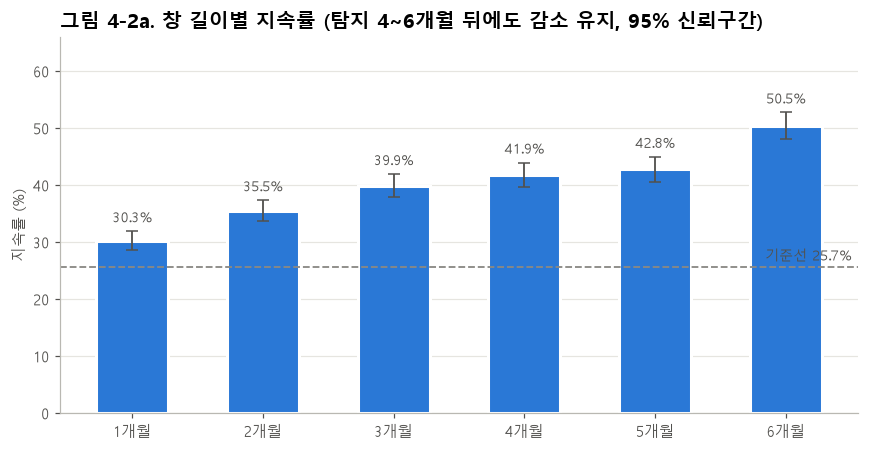

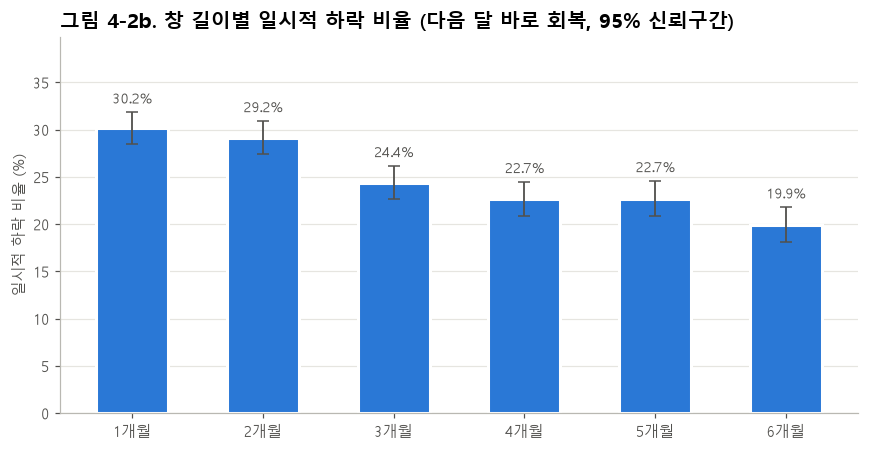

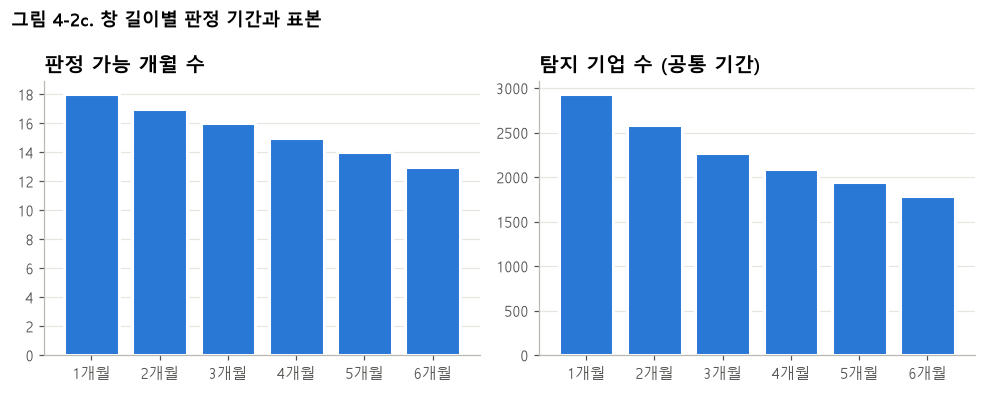

In [56]:
# ④-2-3. 그림
x = np.arange(len(CAND))
xt = [f"{k}개월" for k in CAND]

def ci_bars(ax, col, title, ylabel):
    ax.bar(x, win_tab[col] * 100, width=0.55, color=C1, edgecolor="white", linewidth=2)
    ax.errorbar(x, win_tab[col] * 100,
                yerr=[(win_tab[col] - win_tab[f"{col} 하한"]) * 100, (win_tab[f"{col} 상한"] - win_tab[col]) * 100],
                fmt="none", ecolor=INK, capsize=4, lw=1.2)
    for xi, (p, hi) in enumerate(zip(win_tab[col], win_tab[f"{col} 상한"])):
        ax.annotate(f"{p:.1%}", (xi, hi * 100), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", color=INK, fontsize=9)
    ax.set_xticks(x, xt); ax.set_ylabel(ylabel); ax.set_title(title)
    ax.set_ylim(0, win_tab[f"{col} 상한"].max() * 100 * 1.25)

# 그림 4-2a. 주 지표: 지속률
fig, ax = plt.subplots(figsize=(8, 4.2))
ci_bars(ax, "지속률", "그림 4-2a. 창 길이별 지속률 (탐지 4~6개월 뒤에도 감소 유지, 95% 신뢰구간)", "지속률 (%)")
ax.axhline(BASE_RATE * 100, color=MUTED, ls="--", lw=1.2)
ax.annotate(f"기준선 {BASE_RATE:.1%}", (len(x) - 0.5, BASE_RATE * 100), xytext=(0, 4),
            textcoords="offset points", ha="right", color=INK, fontsize=9)
save(fig, "4-2a_창길이별_지속률")

# 그림 4-2b. 보조 지표: 일시적 하락
fig, ax = plt.subplots(figsize=(8, 4.2))
ci_bars(ax, "일시적 하락", "그림 4-2b. 창 길이별 일시적 하락 비율 (다음 달 바로 회복, 95% 신뢰구간)", "일시적 하락 비율 (%)")
save(fig, "4-2b_창길이별_일시적하락")

# 그림 4-2c. 판정 기간과 표본
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].bar(xt, win_tab["판정 가능 개월 수"], color=C1, edgecolor="white", linewidth=2)
axes[0].set_title("판정 가능 개월 수"); axes[0].yaxis.set_major_locator(mpl.ticker.MaxNLocator(integer=True))
axes[1].bar(xt, win_tab["탐지 기업"], color=C1, edgecolor="white", linewidth=2)
axes[1].set_title("탐지 기업 수 (공통 기간)")
for a in axes: a.title.set_fontsize(11)
fig.suptitle("그림 4-2c. 창 길이별 판정 기간과 표본", x=0.01, ha="left", fontweight="bold")
save(fig, "4-2c_판정기간_표본")

**④-2 결과 해석**

- 창이 길수록 지속률(탐지 4~6개월 뒤에도 감소가 이어진 비율)이 꾸준히 높아졌다: 1개월 30.3% → 3개월 40.0% → 5개월 42.8% → 6개월 50.5%.
- 6개월 창의 지속률은 기준선(약 25.7%)의 1.96배로, 평균 기업보다 지속 감소를 약 2배 잘 가려낸다.
- 1~5개월 창은 모두 6개월 창보다 지속률이 유의하게 낮았다(z 4.7~13.9, p < 0.05). 사전 규칙에 따라 **6개월 창을 채택**한다.
- 보조 지표인 일시적 하락 비율에서도 6개월 창이 가장 낮아(19.9%), 서로 다른 두 기준이 같은 결론을 가리킨다.
- 실제로 지속된 탐지 기업 수는 창 길이와 관계없이 약 900개로 비슷했다(약 887~917개). 창이 길어지며 줄어든 탐지는 대부분 지속되지 않은 탐지(오탐)다. 6개월 창은 의미 있는 기업을 거의 잃지 않고 오탐을 줄인다.
- 대가: 6개월 창은 판정 기간이 13개월로 짧고(3개월 창 16개월), 탐지 시점이 3개월 창보다 중앙값 1개월 늦다.
- 한계 ① 지속률은 정확도만 반영하고 탐지 시점·판정 기간은 반영하지 않는다.
- 한계 ② 표본이 커서 작은 차이도 유의하게 나와, 사실상 지속률이 가장 높은 창이 선택되는 구조다.
- 한계 ③ 5개월(42.8%)에서 6개월(50.5%)로 크게 뛰는 이유는 추가 확인이 필요하다. 판정 첫 달(2024.06)에 오래 감소 중이던 기업이 몰린 효과일 수 있다.
- 3개월 창 결과는 ⑦에서 민감도 분석으로 비교한다.

## ④-3. 금액 하한

- 기준 금액 = 비교 기간 평균 입금 → 10분위
- 분위마다 변화율 IQR(3사분위수 − 1사분위수)
- 기준 IQR = 상위 5개 분위 IQR의 중앙값
- 판정: IQR ≤ 기준 IQR × 1.5 를 만족하기 시작하는 가장 낮은 분위(그 위 분위도 모두 만족)의 하한 금액

In [23]:
ch, base = change(dep, K, METHOD)
TS = first_t(K, METHOD)                           # 이 방식·창의 판정 시작 달
sl = slice(TS, END_T + 1)
v = pd.DataFrame({"base": base[:, sl].ravel(), "ch": ch[:, sl].ravel(),
                  "t": np.tile(np.arange(TS, END_T + 1), N)}).dropna()

v["분위"] = pd.qcut(v["base"], 10, labels=False, duplicates="drop") + 1
q1 = lambda s: s.quantile(.25); q3 = lambda s: s.quantile(.75)
dec = v.groupby("분위").agg(하한금액=("base", "min"), 상한금액=("base", "max"), 관측수=("ch", "size"),
                           Q1=("ch", q1), Q3=("ch", q3))
dec["IQR"] = dec["Q3"] - dec["Q1"]
ref = dec["IQR"].iloc[-5:].median()
dec["기준 충족"] = dec["IQR"] <= IQR_MULT * ref
first_q = next(q for q in dec.index if dec.loc[q:, "기준 충족"].all())
FLOOR = float(dec.loc[first_q, "하한금액"])
excluded = (v["base"] < FLOOR).mean()

decisions["④-3 금액 하한"] = (f"{FLOOR:,.1f}", f"{first_q}분위부터 IQR ≤ 기준 IQR({ref:.3f}) × {IQR_MULT}, 제외 비율 {excluded:.1%}")
print(f"실제 분위 수: {dec.index.max()}개")
display(dec.round(3))
print("→ 채택:", decisions["④-3 금액 하한"])

실제 분위 수: 10개


,하한금액,상한금액,관측수,Q1,Q3,IQR,기준 충족
분위,,,,,,,
1,0.002,6.667,4366,-0.188,0.802,0.990,False
2,6.667,21.467,4324,-0.305,0.440,0.744,False
3,21.483,48.833,4347,-0.264,0.402,0.666,False
4,48.860,82.667,4347,-0.272,0.243,0.514,True
5,82.700,128.333,4351,-0.254,0.262,0.516,True
6,128.417,193.500,4337,-0.278,0.175,0.453,True
7,193.533,293.667,4343,-0.232,0.191,0.423,True
8,293.700,480.000,4351,-0.238,0.140,0.378,True
9,480.167,991.667,4339,-0.262,0.101,0.363,True


→ 채택: ('48.9', '4분위부터 IQR ≤ 기준 IQR(0.378) × 1.5, 제외 비율 30.0%')


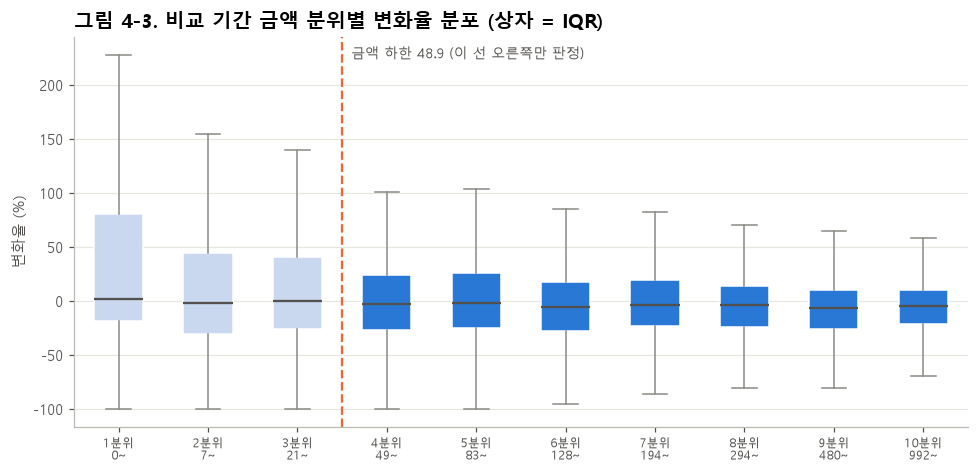

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.4))
data = [v.loc[v["분위"] == q, "ch"].values * 100 for q in dec.index]
bp = ax.boxplot(data, positions=dec.index, widths=0.55, showfliers=False, patch_artist=True,
                medianprops=dict(color=INK, lw=1.5), whiskerprops=dict(color=MUTED),
                capprops=dict(color=MUTED), boxprops=dict(edgecolor="white", lw=1))
for q, b in zip(dec.index, bp["boxes"]):
    b.set_facecolor(C1 if q >= first_q else LIGHT)
ax.axvline(first_q - 0.5, color=C2, lw=1.5, ls="--")
ax.annotate(f"금액 하한 {FLOOR:,.1f} (이 선 오른쪽만 판정)", (first_q - 0.5, 1.0), xycoords=("data", "axes fraction"),
            xytext=(6, -6), textcoords="offset points", color=INK, fontsize=9, va="top",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none"))
ax.set_xticks(dec.index, [f"{q}분위\n{dec.loc[q, '하한금액']:,.0f}~" for q in dec.index], fontsize=8)
ax.set_ylabel("변화율 (%)")
ax.set_title("그림 4-3. 비교 기간 금액 분위별 변화율 분포 (상자 = IQR)")
save(fig, "4-3_금액분위별_변화율")

**④-3 결과 해석**

- 비교 기간 월평균 입금이 작은 기업일수록 변화율이 크게 흔들린다. 1분위(0~6.7백만원)의 IQR은 99%p로, 절반의 기업이 작년 대비 −19%~+80% 사이에서 움직인다. 이 구간에서는 30~50% 감소도 흔한 변동이다.
- 원인: 기준 금액이 작아 몇백만 원 변화도 큰 비율로 나타나고, 금액이 구간 단위로 반올림되어 있어 작은 금액일수록 반올림 영향이 크다.
- 기준 IQR(상위 5개 분위 IQR 중앙값) 0.378 × 1.5 = 0.567 이내로 들어오는 첫 분위는 4분위(IQR 0.51)다. 따라서 **금액 하한을 48.9백만원**(비교 기간 월평균 입금 약 4,900만원)으로 정한다.
- 하한 적용으로 판정 대상 기업-월의 30%가 제외된다. 제외되는 쪽은 변화율이 불안정한 소규모 입금 구간이라, 오탐을 줄이는 효과가 있다.
- 이후 결과는 "월평균 입금 약 4,900만원 이상 법인"에 대한 결론으로 해석한다.
- 한계: IQR이 4분위 이후에도 완만하게 줄어 뚜렷한 경계는 없다. 하한 위치는 허용 배수(1.5배)에 따라 달라질 수 있으므로, ⑦에서 하한을 바꿔도 결론이 유지되는지 확인한다.

## ④-4. 판정 기간

In [25]:
decisions["④-4 판정 기간"] = (f"{label[TS]} ~ {label[END_T]}", f"{END_T - TS + 1}개월 (사후 추적 {FOLLOW}개월 확보)")
print("→", decisions["④-4 판정 기간"])

→ ('2024.06 ~ 2025.06', '13개월 (사후 추적 6개월 확보)')


## ④-5. 변화율 분포 요약

금액 하한 이상인 기업-월만 사용합니다. 변화율은 아래로 −100%에서 막히고 위로는 제한이 없어 오른쪽으로 치우치므로 중앙값·분위수 중심으로 봅니다.

In [26]:
u = v[v["base"] >= FLOOR].copy()
summary = u["ch"].describe(percentiles=[.01, .05, .10, .25, .5, .75, .90])
summary["왜도"] = stats.skew(u["ch"])
P5 = u["ch"].quantile(.05)

# ⑤-1 미리보기: 연도별 5번째 백분위수
u["연"] = [label[t][:4] for t in u["t"]]
p5_year = u.groupby("연")["ch"].quantile(.05)

decisions["④-5 변화율 5번째 백분위수"] = (f"{P5:.1%}", "⑤-1 n% 후보 (5%p 단위 반올림 전)")
display(summary.to_frame("변화율").T.round(4))
print("연도별 5번째 백분위수:", p5_year.round(4).to_dict())

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,max,왜도
변화율,30413.0,0.0451,0.7891,-1.0,-0.9325,-0.711,-0.5223,-0.2488,-0.0426,0.1667,0.5121,29.7401,9.9022


연도별 5번째 백분위수: {'2024': -0.7146, '2025': -0.7026}


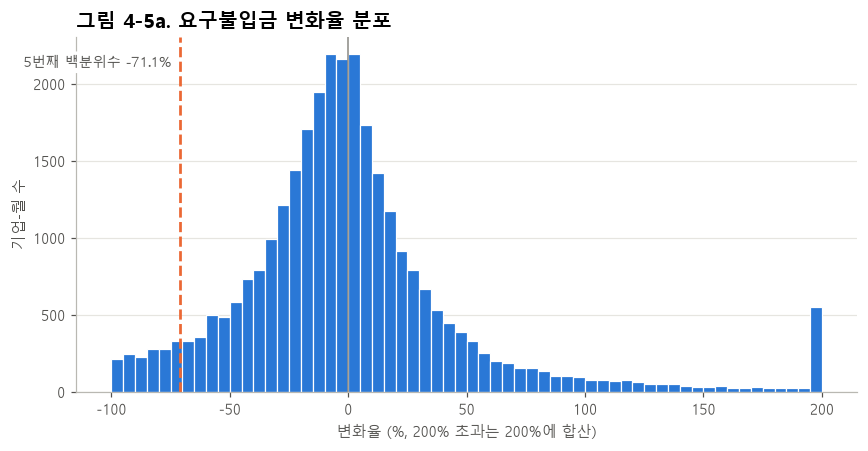

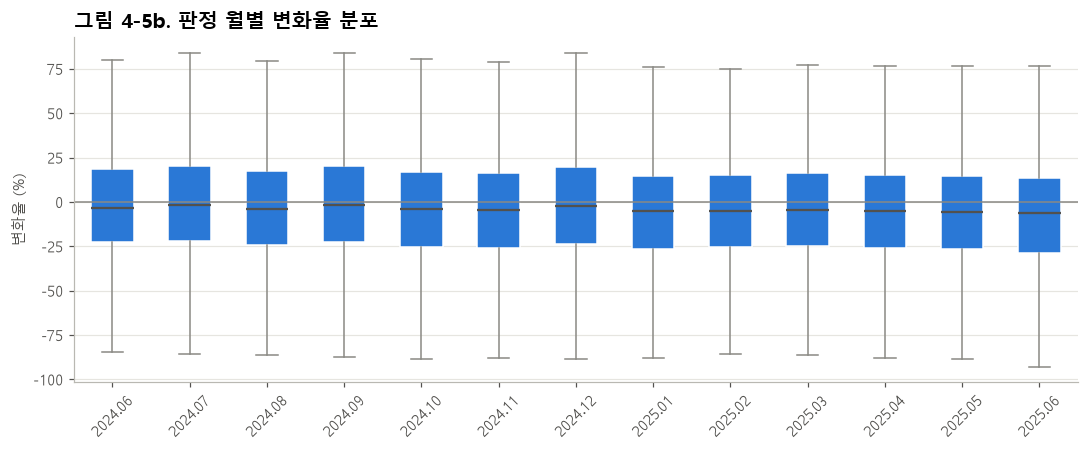

In [27]:
fig, ax = plt.subplots(figsize=(8, 4.2))
clip = u["ch"].clip(-1, 2) * 100
ax.hist(clip, bins=np.arange(-100, 205, 5), color=C1, edgecolor="white", linewidth=0.8)
ax.axvline(P5 * 100, color=C2, lw=1.8, ls="--")
ax.annotate(f"5번째 백분위수 {P5:.1%}", (P5 * 100, ax.get_ylim()[1] * 0.95), xytext=(-6, 0),
            textcoords="offset points", color=INK, fontsize=9, va="top", ha="right",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none"))
ax.axvline(0, color=MUTED, lw=1)
ax.set_xlabel("변화율 (%, 200% 초과는 200%에 합산)")
ax.set_ylabel("기업-월 수")
ax.set_title("그림 4-5a. 요구불입금 변화율 분포")
save(fig, "4-5a_변화율_히스토그램")

fig, ax = plt.subplots(figsize=(10, 4.2))
ts = sorted(u["t"].unique())
ax.boxplot([u.loc[u["t"] == t, "ch"].values * 100 for t in ts], positions=range(len(ts)), widths=0.55,
           showfliers=False, patch_artist=True, medianprops=dict(color=INK, lw=1.5),
           boxprops=dict(facecolor=C1, edgecolor="white"), whiskerprops=dict(color=MUTED), capprops=dict(color=MUTED))
ax.axhline(0, color=MUTED, lw=1)
ax.set_xticks(range(len(ts)), [label[t] for t in ts], rotation=45)
ax.set_ylabel("변화율 (%)")
ax.set_title("그림 4-5b. 판정 월별 변화율 분포")
save(fig, "4-5b_월별_변화율_상자그림")

**④-5 결과 해석**

- 6개월 평균 입금 변화율(작년 같은 6개월 대비)은 0% 바로 아래에 가장 많이 몰려 있고 대부분 ±30% 안에 있다. 보통 기업은 작년과 비슷하거나 약간 줄어든 수준이다.
- 오른쪽으로 긴 꼬리(200% 초과는 200%에 합산)가 있어 평균보다 중앙값·분위수로 해석한다.
- 왼쪽 끝(−100~−70%)에 입금이 거의 끊긴 기업들이 두꺼운 꼬리를 이룬다. 위축 탐지의 주 대상이다.
- **5번째 백분위수는 −71.1%**다. 평소라면 100곳 중 5곳만 이만큼 감소한다는 의미로, ⑤-1의 n% 후보(5%p 단위 반올림 시 70%)가 된다.
- 판정 월별 분포는 모양이 거의 같아(중앙값 −2~−6%), 작년 같은 달 비교와 6개월 평균이 계절 영향을 잘 걸러냈다. 여러 달을 모아 기준을 정해도 된다.
- 2025년으로 갈수록 분포가 약간 아래로 이동한다. 연도별 5번째 백분위수 차이를 ⑤-1 안정성 확인에서 점검한다.
- n이 70% 안팎이면 거의 끊긴 감소만 잡는 엄격한 기준이 된다. ⑤에서 탐지 기업 수가 검정과 유형 분류에 충분한지 함께 확인한다.

## 결정 사항 요약

In [65]:
# ④-2 근거를 지속률 기준으로 갱신
if "지속률" in win_tab.columns:                     # 지속률 버전 ④-2 셀을 실행한 경우: 결과로 자동 작성
    w = win_tab.set_index("창")
    others = [k for k in w.index if k != K]
    decisions["④-2 창 길이"] = (
        f"{K}개월",
        f"지속률(탐지 4~6개월 뒤에도 감소 유지)이 가장 높음: {w.loc[K, '지속률']:.1%}"
        + (f"(기준선 대비 {w.loc[K, '지속비']:.2f}배)" if "지속비" in w.columns else "")
        + f", 나머지 창({min(others)}~{max(others)}개월)은 유의하게 낮음 | "
        f"판정 {int(w.loc[K, '판정 가능 개월 수'])}개월, 탐지 기업 {int(w.loc[K, '탐지 기업']):,}개"
    )
else:                                               # 예전 ④-2 셀인 경우: 실행 결과값으로 고정 작성
    decisions["④-2 창 길이"] = (
        "6개월",
        "지속률(탐지 4~6개월 뒤에도 감소 유지)이 가장 높음: 50.5%(기준선 대비 1.96배), "
        "1~5개월 창은 유의하게 낮음(z 4.7~13.9) | 보조 지표 일시적 하락 19.9%로 최저, "
        "판정 13개월, 탐지 기업 1,786개"
    )

result = pd.DataFrame([(k, *v_) for k, v_ in decisions.items()], columns=["단계", "결정", "근거"])
if SAVE:
    result.to_csv(OUT_DIR / "04_결정사항.csv", index=False, encoding="utf-8-sig")
    idx.round(4).to_csv(OUT_DIR / "4-1_월별지수.csv", encoding="utf-8-sig")
    corr_tab.to_csv(OUT_DIR / "4-1_상관검정.csv", index=False, encoding="utf-8-sig")
    method_tab.to_csv(OUT_DIR / "4-1_비교방식.csv", index=False, encoding="utf-8-sig")
    win_tab.to_csv(OUT_DIR / "4-2_창길이.csv", index=False, encoding="utf-8-sig")
    dec.to_csv(OUT_DIR / "4-3_금액분위.csv", encoding="utf-8-sig")
    summary.to_csv(OUT_DIR / "4-5_변화율요약.csv", encoding="utf-8-sig")

pd.set_option("display.max_colwidth", None)         # 근거 문장이 잘리지 않게
result

,단계,결정,근거
0,④-1 비교 기준,작년 같은 달,계절성 있음 → 월별 탐지율이 덜 흔들리는 방식
1,④-2 창 길이,6개월,"지속률(탐지 4~6개월 뒤에도 감소 유지)이 가장 높음: 50.5%(기준선 대비 1.96배), 나머지 창(1~5개월)은 유의하게 낮음 | 판정 13개월, 탐지 기업 1,786개"
2,④-3 금액 하한,48.9,"4분위부터 IQR ≤ 기준 IQR(0.378) × 1.5, 제외 비율 30.0%"
3,④-4 판정 기간,2024.06 ~ 2025.06,13개월 (사후 추적 6개월 확보)
4,④-5 변화율 5번째 백분위수,-71.1%,⑤-1 n% 후보 (5%p 단위 반올림 전)


## ⑦ 임시값 재확인 (⑤에서 n%가 정해진 뒤 실행)

④-1, ④-2는 임시 감소 기준 30%로 정했습니다. `FINAL_N`에 ⑤에서 확정한 n을 넣고 실행해, 비교 기준과 창 길이 결정이 그대로인지 확인합니다.

In [64]:
FINAL_N = None          # 예: 0.45  (⑤에서 확정한 값)

if FINAL_N is not None:
    mt, _ = compare_methods(K_TEMP, -FINAL_N)
    m2 = mt.loc[mt["최대/최소"].idxmin(), "mode"] if seasonal else "prev"
    wt = window_table(-FINAL_N)
    k2, _ = choose_window(wt)
    display(mt.drop(columns="mode").round(4)); display(wt.round(4))
    print("비교 기준:", "유지" if m2 == METHOD else f"변경 ({METHOD} → {m2})")
    print("창 길이:", "유지" if k2 == K else f"변경 ({K} → {k2})")
else:
    print("FINAL_N을 입력하면 실행됩니다.")

FINAL_N을 입력하면 실행됩니다.
